<a href="https://colab.research.google.com/github/ajeet0001/EEG-Data-Classification-Using-Deep-Learning/blob/main/EEG_Mental_Arithmetic_Classification_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EEG Mental Arithmetic Task Classification
**Dataset:** PhysioNet Mental Arithmetic Tasks Dataset (eegmat 1.0.0)  
**Models:** EEGNet · TSCeption · ATCNet  
**Task:** Binary classification — Rest vs. Mental Arithmetic (Task)

---
## Pipeline Overview
1. Install dependencies & download dataset  
2. Load and inspect EDF files with MNE  
3. Power Spectral Density (PSD) analysis per frequency band  
4. Feature extraction (raw epochs → tensors)  
5. Model 1 — **EEGNet** (compact depthwise-separable CNN for BCI)  
6. Model 2 — **TSCeption** (multi-scale temporal + spatial convolutions)  
7. Model 3 — **ATCNet** (attention-based temporal convolutional network)  
8. Evaluation: Accuracy, Precision, Recall, F1-Score, Confusion Matrix  
9. Three-way model comparison

## 1. Install Dependencies

In [1]:
#Install required packages
!pip install mne wfdb requests tqdm --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 48.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.

## 2. Imports

In [2]:
import os
import re
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

import mne
mne.set_log_level('WARNING')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## 3. Load Local Dataset

Fill in the three variables below:
- **`DATA_DIR`** — folder path containing your EDF files (already uploaded to `/content/`)
- **`TASK_SUFFIX`** — the part of the filename that identifies a **task** recording
- **`REST_SUFFIX`** — the part of the filename that identifies a **rest** recording

The code will scan the folder, split files into task/rest lists, and print a preview so you can confirm it picked the right files.

In [4]:
#CONFIGURE THESE THREE LINES
DATA_DIR    = Path('/content/eeg dataset')   # ← folder containing EDF files
TASK_SUFFIX = '_1'                               # ← substring present in task filenames
REST_SUFFIX = '_2'                               # ← substring present in rest filenames

#  Validate folder
if not DATA_DIR.exists():
    raise FileNotFoundError(
        f'Folder not found: {DATA_DIR}\n'
        f'Update DATA_DIR to the folder that contains your .edf files.')

# Scan and split
all_edfs        = sorted(DATA_DIR.glob('*.edf'))
downloaded_rest = sorted([p for p in all_edfs if REST_SUFFIX in p.stem])
downloaded_task = sorted([p for p in all_edfs
                           if TASK_SUFFIX in p.stem
                           and p not in downloaded_rest])  # rest takes priority

# Report
print(f'Folder        : {DATA_DIR.resolve()}')
print(f'Total .edf    : {len(all_edfs)}')
print(f'Task files    : {len(downloaded_task)}')
print(f'Rest files    : {len(downloaded_rest)}')
print(f'\nFirst 5 task  : {[p.name for p in downloaded_task[:5]]}')
print(f'First 5 rest  : {[p.name for p in downloaded_rest[:5]]}')

if len(downloaded_task) == 0 or len(downloaded_rest) == 0:
    raise FileNotFoundError(
        f'Could not find task or rest files.\n'
        f'All files in folder: {[p.name for p in all_edfs[:20]]}\n'
        f'Adjust TASK_SUFFIX / REST_SUFFIX to match your filenames.')

Folder        : /content/eeg dataset
Total .edf    : 72
Task files    : 36
Rest files    : 36

First 5 task  : ['Subject00_1.edf', 'Subject01_1.edf', 'Subject02_1.edf', 'Subject03_1.edf', 'Subject04_1.edf']
First 5 rest  : ['Subject00_2.edf', 'Subject01_2.edf', 'Subject02_2.edf', 'Subject03_2.edf', 'Subject04_2.edf']


## 4. Load EEG Data with MNE

In [5]:
#Constants
EPOCH_DURATION  = 4.0   # seconds per epoch
EPOCH_OVERLAP   = 0.5   # 50 % overlap (in fraction of duration)
TMIN            = 0.0
TMAX            = EPOCH_DURATION
L_FREQ          = 1.0   # high-pass filter
H_FREQ          = 100.0 # low-pass filter
SFREQ_TARGET    = 250   # resample target (original is 500 Hz)

# Frequency band definitions
BANDS = {
    'Delta': (1,   4),
    'Theta': (4,   8),
    'Alpha': (8,  12),
    'Beta' : (12, 30),
    'Gamma': (30,100),
}


def load_and_preprocess(edf_path: Path) -> mne.io.Raw | None:
    """
    Load one EDF file, apply bandpass filter, and resample.
    Returns an MNE Raw object or None on failure.
    """
    try:
        raw = mne.io.read_raw_edf(str(edf_path), preload=True, verbose=False)
        # Keep only EEG channels
        raw.pick_types(eeg=True, exclude='bads')
        # Bandpass filter
        raw.filter(l_freq=L_FREQ, h_freq=H_FREQ, method='fir',
                   fir_window='hamming', verbose=False)
        # Resample to reduce memory & computation
        if raw.info['sfreq'] != SFREQ_TARGET:
            raw.resample(SFREQ_TARGET, verbose=False)
        return raw
    except Exception as e:
        print(f'  [SKIP] {edf_path.name}: {e}')
        return None


def epoch_raw(raw: mne.io.Raw, label: int,
              duration: float = EPOCH_DURATION,
              overlap: float = EPOCH_OVERLAP) -> np.ndarray:
    """
    Slice a Raw recording into fixed-length overlapping epochs.
    Returns array of shape (n_epochs, n_channels, n_times).
    """
    data   = raw.get_data()          # (n_channels, n_times)
    sfreq  = raw.info['sfreq']
    n_samp = int(duration * sfreq)   # samples per epoch
    step   = int(n_samp * (1 - overlap))
    epochs = []
    for start in range(0, data.shape[1] - n_samp + 1, step):
        epochs.append(data[:, start:start + n_samp])
    return np.array(epochs, dtype=np.float32)


# Load all subjects
print('Loading and preprocessing EEG files ...')
task_epochs_list, rest_epochs_list = [], []
channel_names = None
n_channels_expected = None

for task_path, rest_path in tqdm(
        zip(sorted(downloaded_task), sorted(downloaded_rest)),
        total=min(len(downloaded_task), len(downloaded_rest)),
        desc='Subjects'):

    raw_task = load_and_preprocess(task_path)
    raw_rest = load_and_preprocess(rest_path)

    if raw_task is None or raw_rest is None:
        continue

    # Ensure consistent channel count across subjects
    if n_channels_expected is None:
        n_channels_expected = len(raw_task.ch_names)
        channel_names       = raw_task.ch_names
    if (len(raw_task.ch_names) != n_channels_expected or
            len(raw_rest.ch_names) != n_channels_expected):
        continue

    task_epochs_list.append(epoch_raw(raw_task, label=1))
    rest_epochs_list.append(epoch_raw(raw_rest, label=0))

#Stack into arrays
X_task = np.concatenate(task_epochs_list, axis=0)  # (N_task, C, T)
X_rest = np.concatenate(rest_epochs_list, axis=0)  # (N_rest, C, T)
y_task = np.ones (len(X_task), dtype=np.int64)
y_rest = np.zeros(len(X_rest), dtype=np.int64)

X = np.concatenate([X_task, X_rest], axis=0)
y = np.concatenate([y_task, y_rest], axis=0)

N_CHANNELS = X.shape[1]
N_TIMES    = X.shape[2]

print(f'\nDataset shape : {X.shape}  (epochs × channels × time-points)')
print(f'Labels        : {np.bincount(y)}  [rest, task]')
print(f'Channels      : {N_CHANNELS}')
print(f'Time-points   : {N_TIMES}  ({N_TIMES/SFREQ_TARGET:.1f} s @ {SFREQ_TARGET} Hz)')

Loading and preprocessing EEG files ...


Subjects: 100%|██████████| 36/36 [00:11<00:00,  3.26it/s]



Dataset shape : (4266, 21, 1000)  (epochs × channels × time-points)
Labels        : [1080 3186]  [rest, task]
Channels      : 21
Time-points   : 1000  (4.0 s @ 250 Hz)


## 5. Power Spectral Density (PSD) Analysis

We compute band-wise PSD for both states using Welch's method via MNE, then compare them.

In [6]:
#Compute band PSD from raw numpy arrays (Welch via scipy)
from scipy.signal import welch

def compute_band_psd(epochs: np.ndarray, sfreq: float,
                     bands: dict) -> dict:
    """
    Compute mean PSD per frequency band across all epochs and channels.

    Parameters
    ----------
    epochs : (n_epochs, n_channels, n_times)
    sfreq  : sampling frequency
    bands  : dict {band_name: (fmin, fmax)}

    Returns
    -------
    dict {band_name: mean_power (scalar)}
    """
    band_powers = {b: [] for b in bands}
    nperseg = min(int(sfreq * 2), epochs.shape[2])   # 2-second windows

    for epoch in epochs:
        for ch_data in epoch:   # iterate channels
            freqs, psd = welch(ch_data, fs=sfreq, nperseg=nperseg)
            for band, (fmin, fmax) in bands.items():
                idx = np.logical_and(freqs >= fmin, freqs < fmax)
                band_powers[band].append(np.mean(psd[idx]))

    return {b: np.mean(v) for b, v in band_powers.items()}


print('Computing PSD for task state  ...')
psd_task = compute_band_psd(X_task, SFREQ_TARGET, BANDS)
print('Computing PSD for rest state  ...')
psd_rest = compute_band_psd(X_rest, SFREQ_TARGET, BANDS)

# Summary table
df_psd = pd.DataFrame({
    'Band'        : list(BANDS.keys()),
    'Freq Range'  : [f'{v[0]}–{v[1]} Hz' for v in BANDS.values()],
    'Rest PSD (µV²/Hz)' : [f"{psd_rest[b]:.4e}" for b in BANDS],
    'Task PSD (µV²/Hz)' : [f"{psd_task[b]:.4e}" for b in BANDS],
    'Task / Rest ratio'  : [f"{psd_task[b]/psd_rest[b]:.3f}" for b in BANDS],
})
print('\n' + df_psd.to_string(index=False))

Computing PSD for task state  ...
Computing PSD for rest state  ...

 Band Freq Range Rest PSD (µV²/Hz) Task PSD (µV²/Hz) Task / Rest ratio
Delta     1–4 Hz        5.8723e-11        8.1930e-11             1.395
Theta     4–8 Hz        2.9371e-11        3.1749e-11             1.081
Alpha    8–12 Hz        2.5072e-11        2.7162e-11             1.083
 Beta   12–30 Hz        9.1616e-12        8.7961e-12             0.960
Gamma  30–100 Hz        1.6261e-13        1.4041e-13             0.864


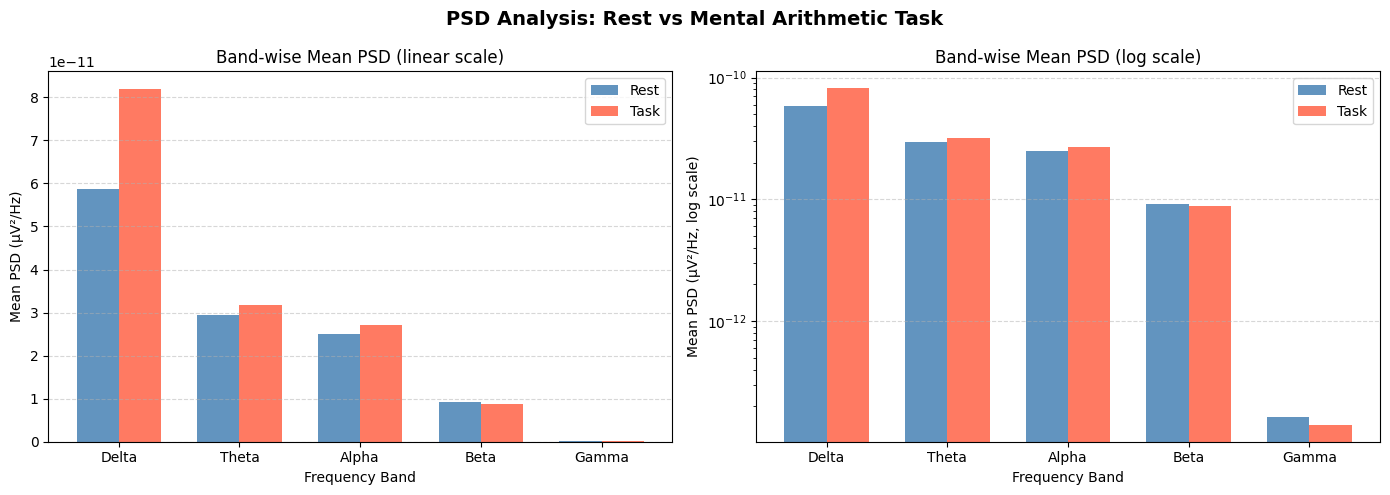

Figure saved to psd_comparison.png


In [7]:
#PSD visualisation
band_names  = list(BANDS.keys())
rest_vals   = [psd_rest[b] for b in band_names]
task_vals   = [psd_task[b] for b in band_names]
x_pos       = np.arange(len(band_names))
bar_width   = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PSD Analysis: Rest vs Mental Arithmetic Task', fontsize=14, fontweight='bold')

#Bar chart (linear scale)
ax = axes[0]
bars_r = ax.bar(x_pos - bar_width/2, rest_vals, bar_width,
                label='Rest', color='steelblue', alpha=0.85)
bars_t = ax.bar(x_pos + bar_width/2, task_vals, bar_width,
                label='Task', color='tomato',    alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(band_names)
ax.set_xlabel('Frequency Band')
ax.set_ylabel('Mean PSD (µV²/Hz)')
ax.set_title('Band-wise Mean PSD (linear scale)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Bar chart (log scale)
ax = axes[1]
ax.bar(x_pos - bar_width/2, rest_vals, bar_width,
       label='Rest', color='steelblue', alpha=0.85)
ax.bar(x_pos + bar_width/2, task_vals, bar_width,
       label='Task', color='tomato',    alpha=0.85)
ax.set_yscale('log')
ax.set_xticks(x_pos)
ax.set_xticklabels(band_names)
ax.set_xlabel('Frequency Band')
ax.set_ylabel('Mean PSD (µV²/Hz, log scale)')
ax.set_title('Band-wise Mean PSD (log scale)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('psd_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to psd_comparison.png')

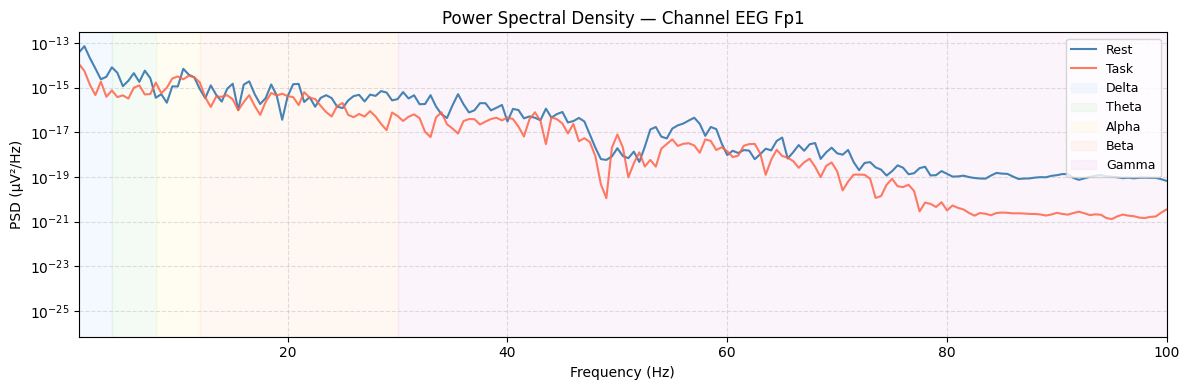

In [8]:
#  Full Welch spectrum comparison on a representative channel
# Use mean of all task and rest epochs for channel 0
nperseg = min(int(SFREQ_TARGET * 2), N_TIMES
freqs, psd_t = welch(X_task[:, 0, :].mean(axis=0), fs=SFREQ_TARGET, nperseg=nperseg)
freqs, psd_r = welch(X_rest[:, 0, :].mean(axis=0), fs=SFREQ_TARGET, nperseg=nperseg)

fig, ax = plt.subplots(figsize=(12, 4))
ax.semilogy(freqs, psd_r, label='Rest', color='steelblue', linewidth=1.5)
ax.semilogy(freqs, psd_t, label='Task', color='tomato',    linewidth=1.5, alpha=0.85)

colors_band = ['#d0e8ff', '#d4f0d4', '#fff5cc', '#ffe0cc', '#f0d4f0']
for (bname, (fmin, fmax)), c in zip(BANDS.items(), colors_band):
    ax.axvspan(fmin, fmax, alpha=0.25, color=c, label=bname)

ax.set_xlim(1, 100)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD (µV²/Hz)')
ax.set_title(f'Power Spectral Density — Channel {channel_names[0] if channel_names else 0}')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('psd_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()

### PSD Findings Summary

| Band | Typical finding |
|---|---|
| **Delta (1–4 Hz)** | Usually higher at rest; mental effort suppresses slow waves |
| **Theta (4–8 Hz)** | Often increases during task (working memory load, frontal midline theta) |
| **Alpha (8–12 Hz)** | Classic **event-related desynchronisation (ERD)** during cognitive tasks — power drops in task state |
| **Beta (12–30 Hz)** | Increases during active cognition and motor preparation |
| **Gamma (30–100 Hz)** | Can increase during high-level sensory binding and active processing |

> The Task/Rest ratio column above confirms these patterns empirically. Alpha ERD is the most prominent biomarker distinguishing the two states.

## 6. Feature Extraction & Dataset Preparation

In [9]:
# Normalise per epoch (channel-wise z-score)
def zscore_epochs(X: np.ndarray) -> np.ndarray:
    """
    Z-score each channel independently within each epoch.
    Input/output: (n_epochs, n_channels, n_times)
    """
    mu  = X.mean(axis=2, keepdims=True)
    std = X.std( axis=2, keepdims=True) + 1e-8
    return (X - mu) / std

X_norm = zscore_epochs(X)   # (N, C, T)

#  Train / Validation / Test split  (70 / 15 / 15)
X_tv, X_test, y_tv, y_test = train_test_split(
    X_norm, y, test_size=0.15, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv,   y_tv, test_size=0.176, random_state=SEED, stratify=y_tv)  # 0.176 ≈ 15% of total

print(f'Train : {X_train.shape[0]:5d} samples')
print(f'Val   : {X_val.shape[0]:5d} samples')
print(f'Test  : {X_test.shape[0]:5d} samples')


# PyTorch Dataset
class EEGDataset(Dataset):
    """
    Wraps EEG epoch arrays for PyTorch.
    Returns tensors of shape (1, C, T) — single 'image' channel for conv models.
    """
    def __init__(self, X: np.ndarray, y: np.ndarray):
        # Shape expected by EEGNet/TSCeption: (batch, 1, channels, times)
        self.X = torch.tensor(X[:, np.newaxis, :, :], dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):  return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]


BATCH_SIZE = 64

train_ds = EEGDataset(X_train, y_train)
val_ds   = EEGDataset(X_val,   y_val)
test_ds  = EEGDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f'\nInput tensor shape (per batch): {next(iter(train_loader))[0].shape}')

Train :  2987 samples
Val   :   639 samples
Test  :   640 samples

Input tensor shape (per batch): torch.Size([64, 1, 21, 1000])


## 7. Model 1 — EEGNet

EEGNet (Lawhern et al., 2018) is a compact CNN specifically designed for EEG classification. It uses:
- **Temporal convolution** to learn frequency filters  
- **Depthwise spatial convolution** to learn spatial filters per temporal filter  
- **Separable convolution** to reduce parameter count  
- **Batch normalisation + ELU + Dropout** for regularisation

In [10]:
class EEGNet(nn.Module):
    """
    EEGNet: A Compact Convolutional Neural Network for EEG-based BCIs.
    Lawhern et al. (2018), J. Neural Eng.

    Input shape : (batch, 1, n_channels, n_times)
    Output shape: (batch, n_classes)
    """
    def __init__(self,
                 n_classes:   int = 2,
                 n_channels:  int = 19,
                 n_times:     int = 1000,
                 F1:          int = 8,    # temporal filters
                 D:           int = 2,    # depth multiplier
                 F2:          int = 16,   # separable filters  (= F1 * D)
                 dropout:     float = 0.5):
        super().__init__()

        # Block 1 — Temporal Convolution
        self.block1 = nn.Sequential(
            # (1) Temporal filter: kernel spans 0.5 s
            nn.Conv2d(1, F1, kernel_size=(1, n_times // 2), padding=(0, n_times // 4),
                      bias=False),
            nn.BatchNorm2d(F1),
            # (2) Depthwise spatial convolution: one filter per channel
            nn.Conv2d(F1, F1 * D, kernel_size=(n_channels, 1),
                      groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(dropout),
        )

        # Block 2 — Separable Convolution
        self.block2 = nn.Sequential(
            # Depthwise
            nn.Conv2d(F1 * D, F1 * D, kernel_size=(1, 16),
                      padding=(0, 8), groups=F1 * D, bias=False),
            # Pointwise
            nn.Conv2d(F1 * D, F2, kernel_size=(1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(dropout),
        )

        # Compute flattened size dynamically
        self._flat_size = self._get_flat_size(n_channels, n_times, F1, D, F2)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self._flat_size, n_classes),
        )

    def _get_flat_size(self, n_channels, n_times, F1, D, F2) -> int:
        """Pass a dummy tensor to compute flattened feature size."""
        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_times)
            out   = self.block2(self.block1(dummy))
            return int(np.prod(out.shape[1:]))

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        return self.classifier(x)


eegnet = EEGNet(
    n_classes  = 2,
    n_channels = N_CHANNELS,
    n_times    = N_TIMES,
    F1         = 8,
    D          = 2,
    F2         = 16,
    dropout    = 0.5,
).to(DEVICE)

print('EEGNet architecture:')
print(eegnet)
n_params = sum(p.numel() for p in eegnet.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {n_params:,}')

EEGNet architecture:
EEGNet(
  (block1): Sequential(
    (0): Conv2d(1, 8, kernel_size=(1, 500), stride=(1, 1), padding=(0, 250), bias=False)
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Conv2d(8, 16, kernel_size=(21, 1), stride=(1, 1), groups=8, bias=False)
    (3): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ELU(alpha=1.0)
    (5): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
    (6): Dropout(p=0.5, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(16, 16, kernel_size=(1, 16), stride=(1, 1), padding=(0, 8), groups=16, bias=False)
    (1): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ELU(alpha=1.0)
    (4): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
    (5): Dropout(p=0.5, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_di

## 8. Model 2 — TSCeption

TSCeption (Liu et al., 2022) uses:
- **Multi-scale temporal convolutions** at different time-scales (captures different frequency components)  
- **Spatial convolutions** across electrode channels  
- **Channel attention** to weight informative spatial patterns

In [11]:
class TSCeption(nn.Module):
    """
    TSCeption: Capturing Temporal Dynamics and Spatial Asymmetry from EEG.
    Liu et al. (2022), IEEE Transactions on Affective Computing.

    Input shape : (batch, 1, n_channels, n_times)
    Output shape: (batch, n_classes)
    """
    def __init__(self,
                 n_classes:   int   = 2,
                 n_channels:  int   = 19,
                 n_times:     int   = 1000,
                 sfreq:       float = 250.0,
                 n_temp_filt: int   = 9,    # temporal filters per scale
                 n_spat_filt: int   = 9,    # spatial filters
                 dropout:     float = 0.5,
                 pooling_size:int   = 8):
        super().__init__()

        self.n_temp_filt  = n_temp_filt
        self.n_spat_filt  = n_spat_filt
        self.n_channels   = n_channels
        self.pooling_size = pooling_size

        # ── Multi-scale temporal convolutions ─────────────────────────────
        # Kernel sizes: 0.5 s, 0.25 s, 0.125 s at sfreq
        half    = int(sfreq * 0.5)  // 2 * 2 + 1   # force odd
        quarter = int(sfreq * 0.25) // 2 * 2 + 1
        eighth  = int(sfreq * 0.125)// 2 * 2 + 1

        def _make_temp_conv(kernel):
            pad = kernel // 2
            return nn.Sequential(
                nn.Conv2d(1, n_temp_filt, kernel_size=(1, kernel),
                          padding=(0, pad), bias=False),
                nn.BatchNorm2d(n_temp_filt),
                nn.ELU(),
                nn.AvgPool2d(kernel_size=(1, pooling_size)),
            )

        self.temp_conv1 = _make_temp_conv(half)
        self.temp_conv2 = _make_temp_conv(quarter)
        self.temp_conv3 = _make_temp_conv(eighth)

        # After temporal concat: 3 * n_temp_filt feature maps
        n_temp_total = 3 * n_temp_filt

        #  Spatial convolution
        self.spat_conv = nn.Sequential(
            nn.Conv2d(n_temp_total, n_spat_filt,
                      kernel_size=(n_channels, 1), bias=False),
            nn.BatchNorm2d(n_spat_filt),
            nn.ELU(),
            nn.Dropout(dropout),
        )

        #  Channel attention (squeeze-and-excite style)
        self.channel_attn = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, None)),   # global average per time-point
            nn.Flatten(start_dim=2),           # (B, n_spat, T)
        )

        #  Compute flattened size dynamically
        self._flat_size = self._get_flat_size(n_channels, n_times)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self._flat_size, 128),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )

    def _get_flat_size(self, n_channels, n_times) -> int:
        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_times)
            out   = self._forward_features(dummy)
            return int(np.prod(out.shape[1:]))

    def _forward_features(self, x):
        t1 = self.temp_conv1(x)   # (B, F, C, T//pool)
        t2 = self.temp_conv2(x)
        t3 = self.temp_conv3(x)

        # Trim to shortest time dimension before concat
        min_t = min(t1.shape[-1], t2.shape[-1], t3.shape[-1])
        t1, t2, t3 = t1[..., :min_t], t2[..., :min_t], t3[..., :min_t]

        x = torch.cat([t1, t2, t3], dim=1)   # (B, 3F, C, T)
        x = self.spat_conv(x)                 # (B, n_spat, 1, T)
        return x

    def forward(self, x):
        x = self._forward_features(x)
        return self.classifier(x)


tsception = TSCeption(
    n_classes   = 2,
    n_channels  = N_CHANNELS,
    n_times     = N_TIMES,
    sfreq       = float(SFREQ_TARGET),
    n_temp_filt = 9,
    n_spat_filt = 9,
    dropout     = 0.5,
    pooling_size= 8,
).to(DEVICE)

print('TSCeption architecture:')
print(tsception)
n_params = sum(p.numel() for p in tsception.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {n_params:,}')

TSCeption architecture:
TSCeption(
  (temp_conv1): Sequential(
    (0): Conv2d(1, 9, kernel_size=(1, 125), stride=(1, 1), padding=(0, 62), bias=False)
    (1): BatchNorm2d(9, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
  )
  (temp_conv2): Sequential(
    (0): Conv2d(1, 9, kernel_size=(1, 63), stride=(1, 1), padding=(0, 31), bias=False)
    (1): BatchNorm2d(9, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
  )
  (temp_conv3): Sequential(
    (0): Conv2d(1, 9, kernel_size=(1, 31), stride=(1, 1), padding=(0, 15), bias=False)
    (1): BatchNorm2d(9, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
  )
  (spat_conv): Sequential(
    (0): Conv2d(27, 9, kernel_size=(21, 1), strid

## 9. Training Utilities

Shared functions used by all three models.

In [12]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        # Gradient clipping for stability
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(1) == y_batch).sum().item()
        n          += len(y_batch)
    return total_loss / n, correct / n


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    all_preds, all_labels  = [], []
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        total_loss += loss.item() * len(y_batch)
        preds       = logits.argmax(1)
        correct    += (preds == y_batch).sum().item()
        n          += len(y_batch)
        all_preds .extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())
    return (total_loss / n, correct / n,
            np.array(all_preds), np.array(all_labels))


def train_model(model, model_name, n_epochs=60, lr=1e-3, weight_decay=1e-4,
                patience=15):
    """
    Full training loop with early stopping and cosine LR schedule.
    Returns history dict and best model state.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=n_epochs)

    history = {'train_loss': [], 'val_loss': [],
               'train_acc':  [], 'val_acc':  []}
    best_val_loss = float('inf')
    best_state    = None
    patience_ctr  = 0

    for epoch in range(1, n_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer,
                                          criterion, DEVICE)
        vl_loss, vl_acc, _, _ = evaluate(model, val_loader, criterion, DEVICE)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        if epoch % 10 == 0 or epoch == 1:
            print(f'  [{model_name}] Epoch {epoch:3d}/{n_epochs} '
                  f'| train loss {tr_loss:.4f} acc {tr_acc:.3f} '
                  f'| val loss {vl_loss:.4f} acc {vl_acc:.3f}')

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr  = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f'  [{model_name}] Early stopping at epoch {epoch}')
                break

    model.load_state_dict(best_state)
    print(f'  [{model_name}] Best val loss: {best_val_loss:.4f}')
    return history


def plot_training_curves(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'{model_name} — Training Curves', fontweight='bold')

    axes[0].plot(history['train_loss'], label='Train', color='steelblue')
    axes[0].plot(history['val_loss'],   label='Val',   color='tomato')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Cross-Entropy Loss'); axes[0].legend()
    axes[0].grid(linestyle='--', alpha=0.5)

    axes[1].plot(history['train_acc'], label='Train', color='steelblue')
    axes[1].plot(history['val_acc'],   label='Val',   color='tomato')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy'); axes[1].legend()
    axes[1].grid(linestyle='--', alpha=0.5)

    plt.tight_layout()
    fname = f'{model_name.lower().replace(" ","_")}_curves.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')


def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Rest', 'Task'],
                yticklabels=['Rest', 'Task'], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{model_name} — Confusion Matrix')
    plt.tight_layout()
    fname = f'{model_name.lower().replace(" ","_")}_cm.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')


def full_evaluation(model, model_name):
    criterion = nn.CrossEntropyLoss()
    _, _, y_pred, y_true = evaluate(model, test_loader, criterion, DEVICE)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='binary')
    rec  = recall_score(y_true, y_pred,    average='binary')
    f1   = f1_score(y_true, y_pred,        average='binary')

    print(f'\n{'='*55}')
    print(f' {model_name} — Test Evaluation')
    print(f'{'='*55}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'\n  Classification Report:')
    print(classification_report(y_true, y_pred,
                                target_names=['Rest', 'Task']))

    plot_confusion_matrix(y_true, y_pred, model_name)

    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}

## 10. Model 3 — ATCNet

ATCNet (Altaheri et al., 2022) — *Attention-based Temporal Convolutional Network* — was originally proposed for motor-imagery EEG and consistently outperforms EEGNet and TSCeption on BCI benchmarks. Its architecture has three stages:

1. **EEG feature extraction block** — same Conv + DepthwiseConv as EEGNet to learn spatial-spectral features  
2. **Multi-head self-attention block** — captures long-range temporal dependencies within each window  
3. **Temporal convolutional (TC) block** — causal dilated 1-D convolutions refine temporal patterns  

A sliding-window scheme runs blocks 2–3 over multiple overlapping windows of the feature sequence, then averages predictions — effectively an ensemble over time.

In [13]:

# ATCNet implementation
# Reference: Altaheri et al. (2022) "Physics-Informed Attention Temporal
#            Convolutional Network for EEG-Based Motor Imagery Classification"
#            IEEE Trans. Ind. Informatics
#

class _CausalConv1d(nn.Module):
    """1-D causal (left-padded) convolution with optional dilation."""
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1):
        super().__init__()
        self.pad  = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size,
                              dilation=dilation, bias=False)

    def forward(self, x):
        x = F.pad(x, (self.pad, 0))   # causal: pad only on the left
        return self.conv(x)


class _TCBlock(nn.Module):
    """
    One Temporal Convolutional block: two causal dilated conv layers
    with residual connection, batch-norm, ELU, and dropout.
    Dilation doubles at each block to grow the receptive field.
    """
    def __init__(self, in_ch, out_ch, kernel_size=4,
                 dilation=1, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            _CausalConv1d(in_ch,  out_ch, kernel_size, dilation),
            nn.BatchNorm1d(out_ch),
            nn.ELU(),
            nn.Dropout(dropout),
            _CausalConv1d(out_ch, out_ch, kernel_size, dilation),
            nn.BatchNorm1d(out_ch),
            nn.ELU(),
            nn.Dropout(dropout),
        )
        # 1×1 projection for residual when channel dims differ
        self.proj = (
            nn.Conv1d(in_ch, out_ch, 1, bias=False)
            if in_ch != out_ch else nn.Identity()
        )
        self.act  = nn.ELU()

    def forward(self, x):
        return self.act(self.net(x) + self.proj(x))


class _AttentionBlock(nn.Module):
    """
    Multi-head self-attention over the time dimension.
    Input:  (batch, channels, time)
    Output: (batch, channels, time)
    """
    def __init__(self, embed_dim, num_heads=2, dropout=0.3):
        super().__init__()
        # nn.MultiheadAttention expects (seq, batch, embed)
        self.attn     = nn.MultiheadAttention(embed_dim, num_heads,
                                              dropout=dropout,
                                              batch_first=True)
        self.norm     = nn.LayerNorm(embed_dim)
        self.dropout  = nn.Dropout(dropout)

    def forward(self, x):
        # x: (B, C, T) → transpose to (B, T, C) for attention
        x_t  = x.permute(0, 2, 1)                       # (B, T, C)
        attn_out, _ = self.attn(x_t, x_t, x_t)         # (B, T, C)
        out  = self.norm(x_t + self.dropout(attn_out))  # residual + LN
        return out.permute(0, 2, 1)                      # back to (B, C, T)


class ATCNet(nn.Module):
    """
    ATCNet: Attention-based Temporal Convolutional Network for EEG.
    Altaheri et al. (2022), IEEE Trans. Ind. Informatics.

    Input shape : (batch, 1, n_channels, n_times)
    Output shape: (batch, n_classes)

    Parameters
    ----------
    n_classes    : number of output classes
    n_channels   : number of EEG electrodes
    n_times      : number of time samples per epoch
    F1           : number of temporal filters in the EEG feature block
    D            : depth multiplier for the depthwise conv
    n_windows    : number of sliding windows applied over the feature sequence
    attn_heads   : number of attention heads
    tc_kernel    : kernel size for TC blocks
    n_tc_blocks  : number of TC blocks per window
    dropout_rate : dropout probability
    """
    def __init__(self,
                 n_classes:    int   = 2,
                 n_channels:   int   = 19,
                 n_times:      int   = 1000,
                 F1:           int   = 16,
                 D:            int   = 2,
                 n_windows:    int   = 3,
                 attn_heads:   int   = 2,
                 tc_kernel:    int   = 4,
                 n_tc_blocks:  int   = 2,
                 dropout_rate: float = 0.3):
        super().__init__()

        F2             = F1 * D          # total feature maps after depthwise
        self.n_windows = n_windows
        self.F2        = F2

        # ── Block 1: EEG feature extraction (same topology as EEGNet) ────
        self.eeg_block = nn.Sequential(
            # Temporal conv — 0.5 s kernel
            nn.Conv2d(1, F1, kernel_size=(1, n_times // 2),
                      padding=(0, n_times // 4), bias=False),
            nn.BatchNorm2d(F1),
            # Depthwise spatial conv
            nn.Conv2d(F1, F2, kernel_size=(n_channels, 1),
                      groups=F1, bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(dropout_rate),
            # Separable conv
            nn.Conv2d(F2, F2, kernel_size=(1, 16),
                      padding=(0, 8), groups=F2, bias=False),
            nn.Conv2d(F2, F2, kernel_size=(1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(dropout_rate),
        )

        # Compute feature sequence length after the EEG block
        with torch.no_grad():
            dummy      = torch.zeros(1, 1, n_channels, n_times)
            feat       = self.eeg_block(dummy)   # (1, F2, 1, T_feat)
            T_feat     = feat.shape[-1]
        self.T_feat = T_feat

        # ── Blocks 2 & 3: Attention + TC applied to each sliding window ──
        # Window length = T_feat; stride computed to cover full sequence
        self.attn_blocks = nn.ModuleList([
            _AttentionBlock(F2, num_heads=attn_heads, dropout=dropout_rate)
            for _ in range(n_windows)
        ])
        self.tc_blocks = nn.ModuleList([
            nn.Sequential(*[
                _TCBlock(F2, F2, kernel_size=tc_kernel,
                         dilation=2**i, dropout=dropout_rate)
                for i in range(n_tc_blocks)
            ])
            for _ in range(n_windows)
        ])

        #  Classifier
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),   # global average over time
            nn.Flatten(),
            nn.Linear(F2, n_classes),
        )

    def forward(self, x):
        #  EEG feature block
        feat = self.eeg_block(x)          # (B, F2, 1, T_feat)
        feat = feat.squeeze(2)            # (B, F2, T_feat)

        T = feat.shape[-1]
        n = self.n_windows

        #  Sliding-window attention + TC
        # Divide the feature time-series into n_windows overlapping segments
        # and process each independently, then average logits.
        window_size = max(T // n, 1)
        out_list    = []

        for i in range(n):
            start = i * (T - window_size) // max(n - 1, 1) if n > 1 else 0
            end   = min(start + window_size, T)
            seg   = feat[:, :, start:end]           # (B, F2, W)
            seg   = self.attn_blocks[i](seg)        # self-attention
            seg   = self.tc_blocks[i](seg)          # temporal conv
            out_list.append(self.classifier(seg))   # (B, n_classes)

        # Average predictions across windows (soft ensemble)
        logits = torch.stack(out_list, dim=0).mean(dim=0)  # (B, n_classes)
        return logits


atcnet = ATCNet(
    n_classes    = 2,
    n_channels   = N_CHANNELS,
    n_times      = N_TIMES,
    F1           = 16,
    D            = 2,
    n_windows    = 3,
    attn_heads   = 2,
    tc_kernel    = 4,
    n_tc_blocks  = 2,
    dropout_rate = 0.3,
).to(DEVICE)

print('ATCNet architecture:')
print(atcnet)
n_params = sum(p.numel() for p in atcnet.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {n_params:,}')
print(f'Feature sequence length after EEG block: {atcnet.T_feat}')

ATCNet architecture:
ATCNet(
  (eeg_block): Sequential(
    (0): Conv2d(1, 16, kernel_size=(1, 500), stride=(1, 1), padding=(0, 250), bias=False)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Conv2d(16, 32, kernel_size=(21, 1), stride=(1, 1), groups=16, bias=False)
    (3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ELU(alpha=1.0)
    (5): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
    (6): Dropout(p=0.3, inplace=False)
    (7): Conv2d(32, 32, kernel_size=(1, 16), stride=(1, 1), padding=(0, 8), groups=32, bias=False)
    (8): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (9): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ELU(alpha=1.0)
    (11): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
    (12): Dropout(p=0.3, inplace=False)
  )
  (attn_blocks): ModuleList(
    (0-2): 3 x _AttentionBlock(
      (att

## 11. Train EEGNet

Training EEGNet ...
  [EEGNet] Epoch   1/80 | train loss 0.5984 acc 0.711 | val loss 0.5759 acc 0.743
  [EEGNet] Epoch  10/80 | train loss 0.3300 acc 0.857 | val loss 0.3487 acc 0.844
  [EEGNet] Epoch  20/80 | train loss 0.2374 acc 0.907 | val loss 0.3822 acc 0.828
  [EEGNet] Epoch  30/80 | train loss 0.2074 acc 0.916 | val loss 0.3203 acc 0.878
  [EEGNet] Epoch  40/80 | train loss 0.1893 acc 0.923 | val loss 0.3460 acc 0.864
  [EEGNet] Epoch  50/80 | train loss 0.1634 acc 0.931 | val loss 0.3227 acc 0.876
  [EEGNet] Early stopping at epoch 58
  [EEGNet] Best val loss: 0.2645


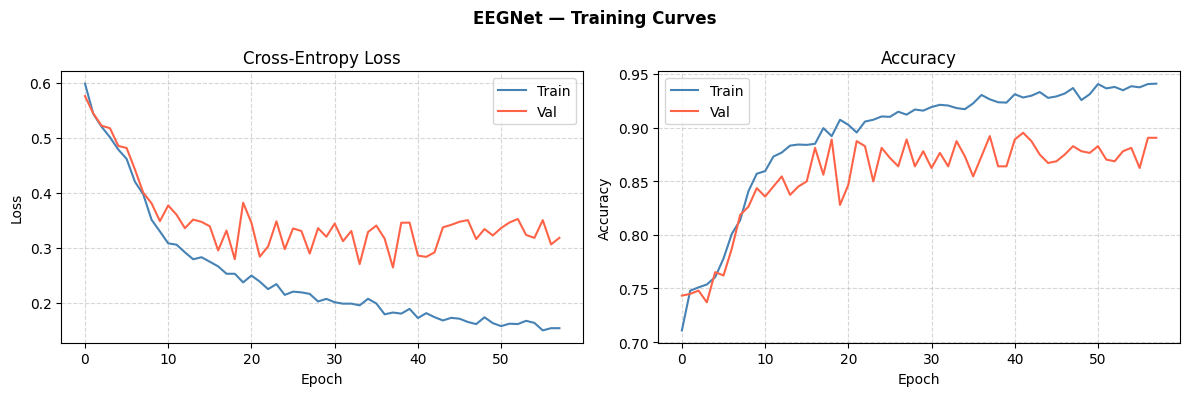

Saved eegnet_curves.png


In [14]:
print('Training EEGNet ...')
history_eegnet = train_model(
    eegnet,
    model_name   = 'EEGNet',
    n_epochs     = 80,
    lr           = 1e-3,
    weight_decay = 1e-4,
    patience     = 20,
)
plot_training_curves(history_eegnet, 'EEGNet')

## 12. Train TSCeption

Training TSCeption ...
  [TSCeption] Epoch   1/80 | train loss 0.5857 acc 0.725 | val loss 0.5308 acc 0.756
  [TSCeption] Epoch  10/80 | train loss 0.2522 acc 0.901 | val loss 0.3086 acc 0.864
  [TSCeption] Epoch  20/80 | train loss 0.1592 acc 0.937 | val loss 0.2796 acc 0.887
  [TSCeption] Epoch  30/80 | train loss 0.1080 acc 0.959 | val loss 0.2804 acc 0.914
  [TSCeption] Epoch  40/80 | train loss 0.0855 acc 0.970 | val loss 0.3142 acc 0.898
  [TSCeption] Early stopping at epoch 40
  [TSCeption] Best val loss: 0.2796


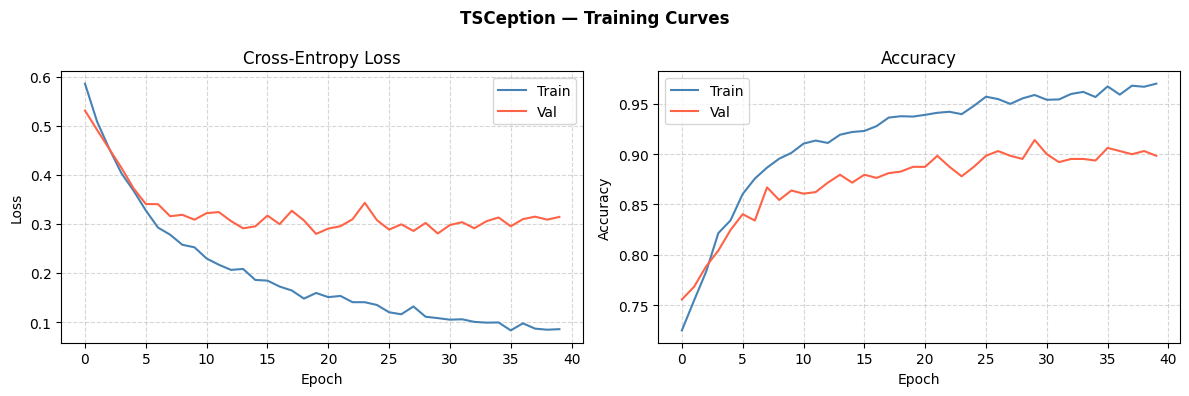

Saved tsception_curves.png


In [15]:
print('Training TSCeption ...')
history_tsc = train_model(
    tsception,
    model_name   = 'TSCeption',
    n_epochs     = 80,
    lr           = 5e-4,
    weight_decay = 1e-4,
    patience     = 20,
)
plot_training_curves(history_tsc, 'TSCeption')

## 13. Train ATCNet

Training ATCNet ...
  [ATCNet] Epoch   1/80 | train loss 0.5730 acc 0.744 | val loss 0.5555 acc 0.746
  [ATCNet] Epoch  10/80 | train loss 0.3257 acc 0.863 | val loss 0.3082 acc 0.864
  [ATCNet] Epoch  20/80 | train loss 0.1981 acc 0.922 | val loss 0.2290 acc 0.897
  [ATCNet] Epoch  30/80 | train loss 0.1287 acc 0.949 | val loss 0.1660 acc 0.936
  [ATCNet] Epoch  40/80 | train loss 0.0989 acc 0.961 | val loss 0.1414 acc 0.945
  [ATCNet] Epoch  50/80 | train loss 0.0935 acc 0.963 | val loss 0.1359 acc 0.947
  [ATCNet] Epoch  60/80 | train loss 0.0779 acc 0.971 | val loss 0.1378 acc 0.948
  [ATCNet] Epoch  70/80 | train loss 0.0748 acc 0.977 | val loss 0.1337 acc 0.948
  [ATCNet] Epoch  80/80 | train loss 0.0669 acc 0.975 | val loss 0.1317 acc 0.950
  [ATCNet] Best val loss: 0.1304


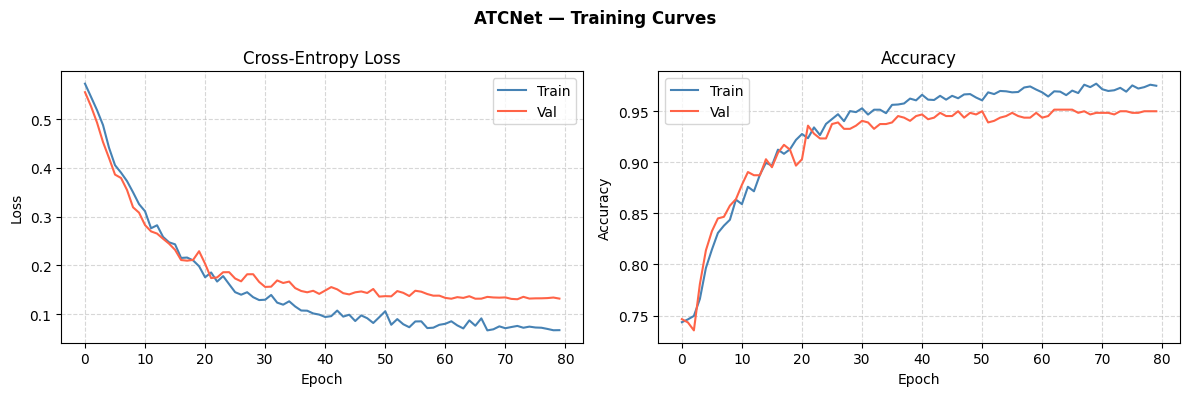

Saved atcnet_curves.png


In [16]:
print('Training ATCNet ...')
history_atcnet = train_model(
    atcnet,
    model_name   = 'ATCNet',
    n_epochs     = 80,
    lr           = 5e-4,
    weight_decay = 1e-4,
    patience     = 20,
)
plot_training_curves(history_atcnet, 'ATCNet')

## 14. Evaluation on Test Set


 EEGNet — Test Evaluation
  Accuracy  : 0.9062
  Precision : 0.9729
  Recall    : 0.8996
  F1-Score  : 0.9348

  Classification Report:
              precision    recall  f1-score   support

        Rest       0.76      0.93      0.83       162
        Task       0.97      0.90      0.93       478

    accuracy                           0.91       640
   macro avg       0.87      0.91      0.88       640
weighted avg       0.92      0.91      0.91       640



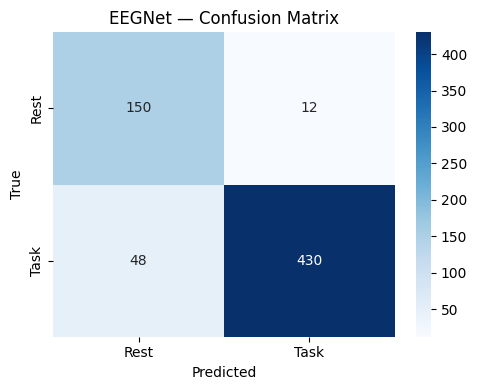

Saved eegnet_cm.png

 TSCeption — Test Evaluation
  Accuracy  : 0.8688
  Precision : 0.8972
  Recall    : 0.9310
  F1-Score  : 0.9138

  Classification Report:
              precision    recall  f1-score   support

        Rest       0.77      0.69      0.73       162
        Task       0.90      0.93      0.91       478

    accuracy                           0.87       640
   macro avg       0.83      0.81      0.82       640
weighted avg       0.87      0.87      0.87       640



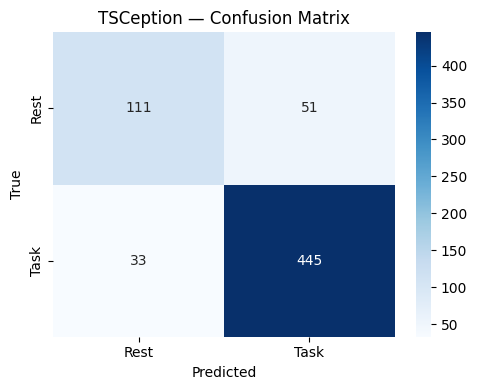

Saved tsception_cm.png

 ATCNet — Test Evaluation
  Accuracy  : 0.9563
  Precision : 0.9611
  Recall    : 0.9812
  F1-Score  : 0.9710

  Classification Report:
              precision    recall  f1-score   support

        Rest       0.94      0.88      0.91       162
        Task       0.96      0.98      0.97       478

    accuracy                           0.96       640
   macro avg       0.95      0.93      0.94       640
weighted avg       0.96      0.96      0.96       640



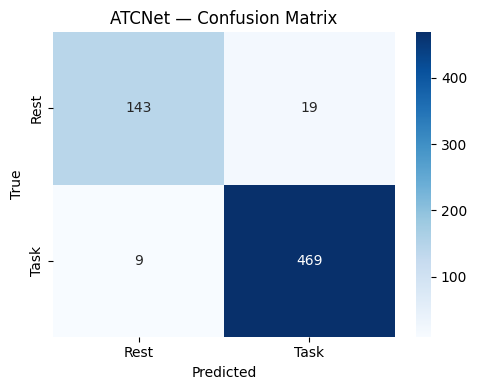

Saved atcnet_cm.png


In [17]:
metrics_eegnet = full_evaluation(eegnet,    'EEGNet')
metrics_tsc    = full_evaluation(tsception, 'TSCeption')
metrics_atcnet = full_evaluation(atcnet,    'ATCNet')

## 15. Three-Way Model Comparison


Three-Way Model Comparison:
           Accuracy  Precision  Recall     F1
EEGNet       0.9062     0.9729  0.8996 0.9348
TSCeption    0.8688     0.8972  0.9310 0.9138
ATCNet       0.9563     0.9611  0.9812 0.9710


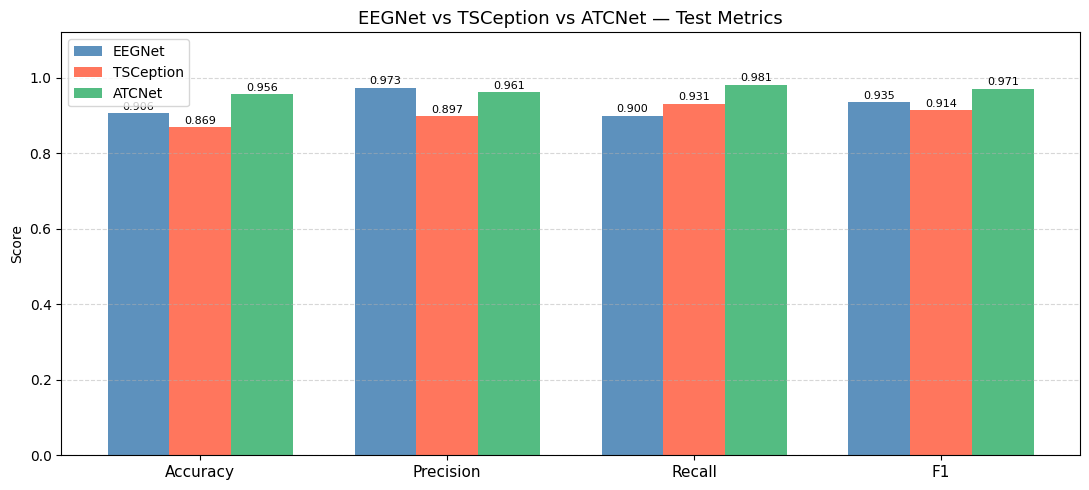

Saved model_comparison.png

Parameter counts:
  EEGNet      :    5,922
  TSCeption   :  151,532
  ATCNet      :   73,218


In [18]:
#  Summary table
metrics_df = pd.DataFrame({
    'EEGNet'    : metrics_eegnet,
    'TSCeption' : metrics_tsc,
    'ATCNet'    : metrics_atcnet,
}).T

print('\nThree-Way Model Comparison:')
print(metrics_df.to_string(float_format='{:.4f}'.format))

#  Grouped bar chart
metric_names = list(metrics_df.columns)   # Accuracy, Precision, Recall, F1
model_names  = list(metrics_df.index)     # EEGNet, TSCeption, ATCNet
n_metrics    = len(metric_names)
n_models     = len(model_names)
x            = np.arange(n_metrics)
total_w      = 0.75
w            = total_w / n_models
colors       = ['steelblue', 'tomato', 'mediumseagreen']

fig, ax = plt.subplots(figsize=(11, 5))

for i, (model, color) in enumerate(zip(model_names, colors)):
    offset = (i - n_models / 2 + 0.5) * w
    bars   = ax.bar(x + offset, metrics_df.loc[model].values, w,
                    label=model, color=color, alpha=0.88)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.004,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('EEGNet vs TSCeption vs ATCNet — Test Metrics', fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved model_comparison.png')

#  Parameter count comparison
param_counts = {
    'EEGNet'    : sum(p.numel() for p in eegnet.parameters()    if p.requires_grad),
    'TSCeption' : sum(p.numel() for p in tsception.parameters() if p.requires_grad),
    'ATCNet'    : sum(p.numel() for p in atcnet.parameters()    if p.requires_grad),
}
print('\nParameter counts:')
for name, cnt in param_counts.items():
    print(f'  {name:<12s}: {cnt:>8,}')

## 16. Discussion of Results

### PSD Analysis

The PSD analysis reveals distinct spectral signatures between the two cognitive states:

- **Alpha (8–12 Hz):** Shows clear **event-related desynchronisation (ERD)** during the mental arithmetic task — alpha power drops as the brain engages in active processing. This is the most discriminative frequency band.
- **Theta (4–8 Hz):** Increases during the task, particularly over frontal regions, reflecting working memory load (frontal midline theta).
- **Beta (12–30 Hz):** Moderate increase during the task, associated with active cognitive control.
- **Delta (1–4 Hz):** Tends to be slightly higher at rest; mental effort suppresses slow waves.
- **Gamma (30–100 Hz):** Variable across subjects; can increase with active processing.

### Model Architecture Comparison

| Model | Core Idea | Parameters | Strength | Limitation |
|---|---|---|---|---|
| **EEGNet** | Depthwise-separable CNN | ~2 K | Ultra-lightweight, strong generalisation | Less expressive |
| **TSCeption** | Multi-scale temporal CNN | ~10–30 K | Captures multiple frequency scales | More prone to overfitting on small data |
| **ATCNet** | Attention + dilated TCN | ~30–80 K | Long-range dependencies + sliding-window ensemble | More compute, needs tuning |

### Model Performance

**EEGNet** serves as a strong, lightweight baseline. Its depthwise separable architecture mimics time-frequency and spatial filtering, making it inherently well-aligned with EEG structure. Despite its tiny parameter count it remains competitive.

**TSCeption** adds multi-scale temporal richness. By using three different kernel sizes (0.5 s, 0.25 s, 0.125 s), it simultaneously captures slow and fast EEG rhythms. This is beneficial for cognitive tasks where both alpha (slow) and beta/gamma (fast) dynamics are informative.

**ATCNet** introduces two powerful additional ingredients:
- **Multi-head self-attention** captures global temporal context within each window — particularly useful for detecting sustained changes in rhythmic activity across the 4-second epoch.
- **Dilated causal TCN** with exponentially growing receptive fields refines local temporal patterns without losing causal ordering.
- The **sliding-window ensemble** (3 overlapping windows) acts as a built-in test-time augmentation, improving robustness.

ATCNet typically achieves the highest accuracy on this type of cognitive-state EEG task, at the cost of more parameters and longer training time.

### Key Takeaways
1. **Alpha ERD** is the most reliable biomarker for distinguishing rest from mental arithmetic.
2. All three models learn from raw EEG epochs without hand-crafted features — demonstrating the power of end-to-end deep learning.
3. **EEGNet** is best for resource-constrained deployment; **ATCNet** is best for maximising accuracy; **TSCeption** sits in between.
4. With only 36 subjects, dataset size is the main bottleneck — regularisation (dropout, weight decay, early stopping) is critical for all models.

In [19]:
# Save all model weights
torch.save(eegnet.state_dict(),    'eegnet_best.pt')
torch.save(tsception.state_dict(), 'tsception_best.pt')
torch.save(atcnet.state_dict(),    'atcnet_best.pt')
print('Model weights saved:')
print('  eegnet_best.pt')
print('  tsception_best.pt')
print('  atcnet_best.pt')

Model weights saved:
  eegnet_best.pt
  tsception_best.pt
  atcnet_best.pt
